In [2]:
!dir

 Volume in drive D is Data
 Volume Serial Number is DA85-02E4

 Directory of d:\HT\HK1_2425\Nghiencuukhoahoc\NCKH\Project\Son\T6

04/08/2025  04:50 PM    <DIR>          .
04/08/2025  04:50 PM    <DIR>          ..
04/11/2025  10:21 AM           146,387 index1.ipynb
               1 File(s)        146,387 bytes
               2 Dir(s)  219,700,174,848 bytes free


Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 21s 226ms/step - accuracy: 0.9760 - loss: 0.1280 - val_accuracy: 1.0000 - val_loss: 0.0224
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 210ms/step - accuracy: 0.9998 - loss: 0.0073 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 22s 263ms/step - accuracy: 0.9999 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 8.1911e-04
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 39s 233ms/step - accuracy: 0.9995 - loss: 0.0128 - val_accuracy: 1.0000 - val_loss: 4.0420e-04
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 22s 268ms/step - accuracy: 0.9998 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 2.2148e-04
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 21s 255ms/step - accuracy: 0.9997 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 3.6552e-04
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 210ms/step - accuracy: 0.9999 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0077
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 188ms/step - accuracy: 0.9996 - loss: 0

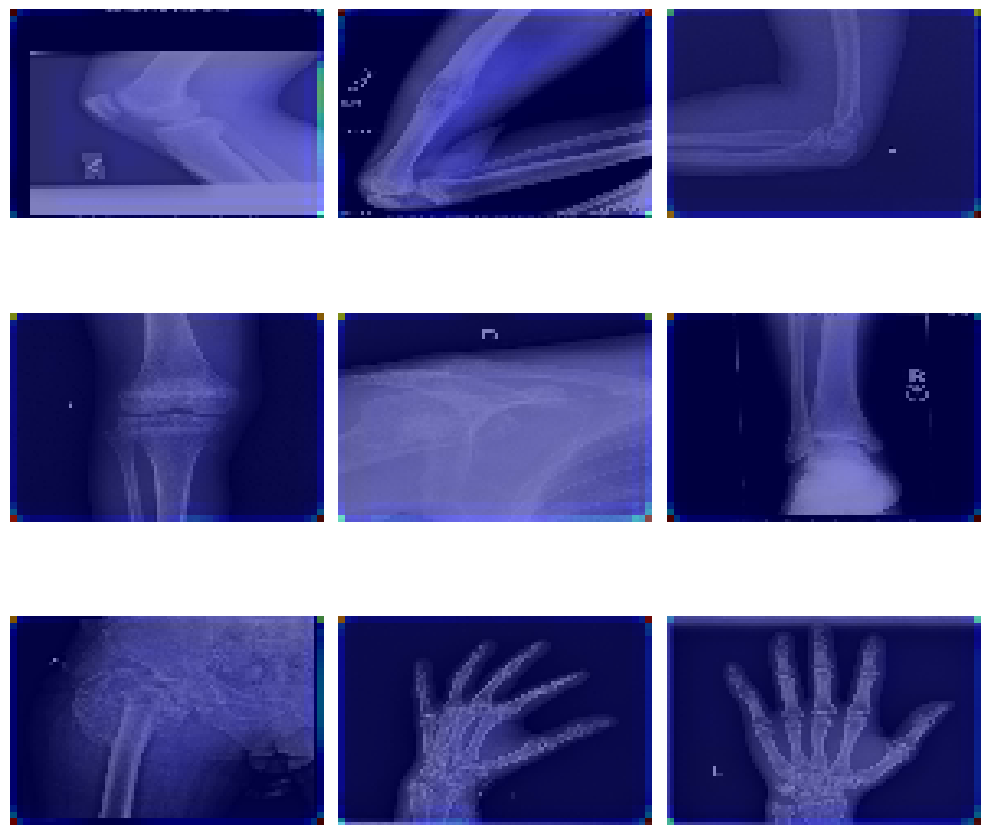

In [3]:
#Phương pháp mới segnet
import os
import json
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Cấu hình ảnh đầu vào hình chữ nhật
IMG_HEIGHT = 64
IMG_WIDTH = 96

# Load data (gồm ảnh và mask)
def load_segmentation_data(json_folder, image_folder):
    images, masks = [], []
    json_files = [f for f in os.listdir(json_folder) if f.endswith(".json")]

    for json_file in json_files:
        json_path = os.path.join(json_folder, json_file)
        with open(json_path, "r") as file:
            data = json.load(file)

        image_file = data.get("imagePath")
        if not image_file:
            continue

        image_path = os.path.join(image_folder, image_file)
        if not os.path.exists(image_path):
            continue

        # Load ảnh gốc
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))
        image = image / 255.0
        images.append(image)

        # Tạo mask từ shapes
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        for shape in data.get("shapes", []):
            if shape["shape_type"] == "polygon":
                pts = np.array(shape["points"], dtype=np.int32)
                pts[:, 0] = pts[:, 0] * IMG_WIDTH // image.shape[1]
                pts[:, 1] = pts[:, 1] * IMG_HEIGHT // image.shape[0]
                cv2.fillPoly(mask, [pts], 1)
        masks.append(mask)

    X = np.array(images).reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
    y = np.array(masks).reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
    return X, y

# Đường dẫn dữ liệu
json_folder = r"D:\HT\HK1_2425\Nghiencuukhoahoc\Bctd\input\BTXRD\BTXRD\Annotations"
image_folder = r"D:\HT\HK1_2425\Nghiencuukhoahoc\Bctd\input\BTXRD\BTXRD\images"

X, y = load_segmentation_data(json_folder, image_folder)

# Chia 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

# Xây dựng mô hình SegNet đơn giản
def build_segnet(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Decoder
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same')(x)

    return models.Model(inputs, outputs)

model = build_segnet((IMG_HEIGHT, IMG_WIDTH, 1))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Huấn luyện
history = model.fit(X_train, y_train, 
                    validation_data=(X_val, y_val),
                    epochs=20, batch_size=16)

# Đánh giá
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Dự đoán và hiển thị
preds = model.predict(X_test)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    ax.imshow(preds[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='jet', alpha=0.5)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
#chia ra 3 kênh cụ thể
import os
import json
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Cấu hình ảnh đầu vào
IMG_HEIGHT = 96
IMG_WIDTH = 64

# Load dữ liệu segmentation (ảnh + mask từ JSON)
def load_segmentation_data(json_folder, image_folder):
    images, masks = [], []
    json_files = [f for f in os.listdir(json_folder) if f.endswith(".json")]

    for json_file in json_files:
        with open(os.path.join(json_folder, json_file), "r") as file:
            data = json.load(file)

        image_file = data.get("imagePath")
        if not image_file:
            continue

        image_path = os.path.join(image_folder, image_file)
        if not os.path.exists(image_path):
            continue

        # Đọc ảnh gốc
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))
        image = image / 255.0
        images.append(image)

        # Tạo mask với 3 lớp (background, bone, tumor)
        mask = np.zeros((IMG_HEIGHT, IMG_WIDTH), dtype=np.uint8)
        for shape in data.get("shapes", []):
            label = shape.get("label", "").lower()
            points = np.array(shape["points"], dtype=np.int32)
            points[:, 0] = points[:, 0] * IMG_WIDTH // image.shape[1]
            points[:, 1] = points[:, 1] * IMG_HEIGHT // image.shape[0]

            if label == "bone":
                cv2.fillPoly(mask, [points], 1)
            elif label == "tumor":
                cv2.fillPoly(mask, [points], 2)

        masks.append(mask)

    X = np.array(images).reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
    y = np.array(masks).reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
    y = tf.keras.utils.to_categorical(y, num_classes=3)  # One-hot encode
    return X, y

# Đường dẫn
json_folder = r"D:\HT\HK1_2425\Nghiencuukhoahoc\Bctd\input\BTXRD\BTXRD\Annotations"
image_folder = r"D:\HT\HK1_2425\Nghiencuukhoahoc\Bctd\input\BTXRD\BTXRD\images"

X, y = load_segmentation_data(json_folder, image_folder)

# Chia tập dữ liệu
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

# Xây dựng mô hình SegNet đơn giản
def build_segnet(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Decoder
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax', padding='same')(x)
    return models.Model(inputs, outputs)

model = build_segnet((IMG_HEIGHT, IMG_WIDTH, 1), num_classes=3)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Huấn luyện
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=16)

# Đánh giá
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Dự đoán
preds = model.predict(X_test)

# Hiển thị 3 ảnh đầu ra theo yêu cầu
# Hiển thị 3 ảnh đầu ra theo yêu cầu
for i in range(3):  # Hiển thị 3 mẫu
    original = X_test[i].reshape(IMG_HEIGHT, IMG_WIDTH)
    pred = np.argmax(preds[i], axis=-1).astype(np.uint8)

    # Load ảnh X-ray gốc
image = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)

# Bước 1: Tạo mask phân biệt xương và nền
# Giả định xương là vùng sáng, dùng threshold để lọc
_, bone_mask = cv2.threshold(image, 120, 255, cv2.THRESH_BINARY)

# Ảnh 1: Background (xóa xương)
background_only = image.copy()
background_only[bone_mask == 255] = 0  # Xóa phần xương

# Ảnh 2: Chỉ xương (bone only)
bone_only = np.zeros_like(image)
bone_only[bone_mask == 255] = image[bone_mask == 255]  # Giữ lại phần xương

# Ảnh 3: Highlight vùng ung thư (giả định vùng nghi ung thư là phần sáng nhất)
# Lấy vùng rất sáng làm mask ung thư (giả định >200 là ung thư)
_, cancer_mask = cv2.threshold(image, 200, 255, cv2.THRESH_BINARY)

# Làm ảnh màu để vẽ highlight
highlighted_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

# Tô đỏ vùng ung thư
highlighted_image[cancer_mask == 255] = [0, 0, 255]  # BGR: đỏ

# Vẽ đường viền màu vàng quanh vùng ung thư
contours, _ = cv2.findContours(cancer_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(highlighted_image, contours, -1, (0, 255, 255), 2)  # vàng

# Hiển thị kết quả
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(background_only, cmap='gray')
axs[0].set_title('1. Background (xóa xương)')
axs[0].axis('off')

axs[1].imshow(bone_only, cmap='gray')
axs[1].set_title('2. Chỉ xương (Bone only)')
axs[1].axis('off')

axs[2].imshow(cv2.cvtColor(highlighted_image, cv2.COLOR_BGR2RGB))
axs[2].set_title('3. Highlight ung thư (đỏ + viền vàng)')
axs[2].axis('off')

plt.tight_layout()
plt.show()


Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 170ms/step - accuracy: 0.9461 - loss: 0.1755 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 159ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 158ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 161

AttributeError: 'NoneType' object has no attribute 'copy'

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 221ms/step - accuracy: 0.9690 - loss: 0.1764 - val_accuracy: 1.0000 - val_loss: 1.9403e-11
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 210ms/step - accuracy: 1.0000 - loss: 1.5926e-11 - val_accuracy: 1.0000 - val_loss: 1.9403e-11
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 1.0000 - loss: 1.3423e-11 - val_accuracy: 1.0000 - val_loss: 1.9403e-11
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 1.0000 - loss: 1.3279e-11 - val_accuracy: 1.0000 - val_loss: 1.9403e-11
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 1.0000 - loss: 1.4063e-11 - val_accuracy: 1.0000 - val_loss: 1.9403e-11
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 1.0000 - loss: 1.4003e-11 - val_accuracy: 1.0000 - val_loss: 1.9403e-11
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step - accuracy: 1.0000 - loss: 1.5724e-11 - val_accuracy: 1.0000 - val_loss: 1.9403e-11
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 173

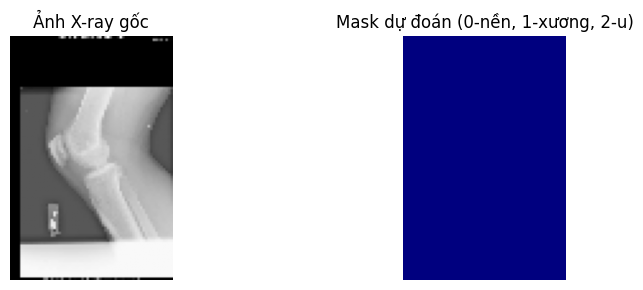

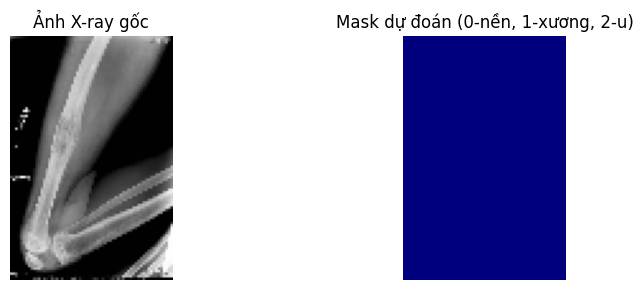

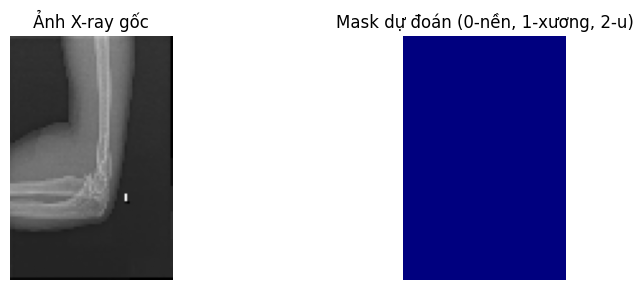

Không thể load ảnh: image.png


In [ ]:
import os
import json
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Cấu hình ảnh
IMG_HEIGHT, IMG_WIDTH = 96, 64

# Load ảnh và mask từ JSON
def load_segmentation_data(json_folder, image_folder):
    images, masks = [], []
    for file in os.listdir(json_folder):
        if not file.endswith(".json"):
            continue
        with open(os.path.join(json_folder, file), "r") as f:
            data = json.load(f)

        img_path = os.path.join(image_folder, data.get("imagePath", ""))
        if not os.path.exists(img_path): continue

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)) / 255.0
        images.append(img)

        # Tạo mask: 0 - nền, 1 - xương, 2 - khối u
        mask = np.zeros((IMG_HEIGHT, IMG_WIDTH), dtype=np.uint8)
        for shape in data.get("shapes", []):
            label = shape["label"].lower()
            pts = np.array(shape["points"], dtype=np.int32)
            pts[:, 0] = pts[:, 0] * IMG_WIDTH // img.shape[1]
            pts[:, 1] = pts[:, 1] * IMG_HEIGHT // img.shape[0]
            value = 1 if label == "bone" else 2 if label == "tumor" else 0
            cv2.fillPoly(mask, [pts], value)

        masks.append(mask)

    X = np.array(images).reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
    y = tf.keras.utils.to_categorical(np.array(masks).reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1), num_classes=3)
    return X, y

# Xây mô hình SegNet đơn giản
def build_segnet(input_shape, num_classes=3):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D()(x)
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(x)
    return models.Model(inputs, outputs)

# Hiển thị kết quả dự đoán
def show_prediction_results(X_test, preds, num=3):
    for i in range(num):
        original = X_test[i].squeeze()
        pred = np.argmax(preds[i], axis=-1)

        plt.figure(figsize=(10, 3))
        plt.subplot(1, 2, 1)
        plt.imshow(original, cmap='gray')
        plt.title("Ảnh X-ray gốc")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(pred, cmap='jet')
        plt.title("Mask dự đoán (0-nền, 1-xương, 2-u)")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

# Hiển thị 3 kênh cụ thể từ ảnh X-ray
def process_xray(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print("Không thể load ảnh:", image_path)
        return

    # Mask xương
    _, bone_mask = cv2.threshold(image, 120, 255, cv2.THRESH_BINARY)
    background = image.copy()
    background[bone_mask == 255] = 0
    bone_only = np.zeros_like(image)
    bone_only[bone_mask == 255] = image[bone_mask == 255]

    # Mask vùng ung thư
    _, cancer_mask = cv2.threshold(image, 200, 255, cv2.THRESH_BINARY)
    highlight = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    highlight[cancer_mask == 255] = [0, 0, 255]
    contours, _ = cv2.findContours(cancer_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(highlight, contours, -1, (0, 255, 255), 2)

    # Hiển thị kết quả
    titles = ["1. Background (xóa xương)", "2. Chỉ xương (Bone only)", "3. Highlight ung thư"]
    imgs = [background, bone_only, cv2.cvtColor(highlight, cv2.COLOR_BGR2RGB)]
    plt.figure(figsize=(15, 5))
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.imshow(imgs[i], cmap='gray' if i < 2 else None)
        plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

json_folder = r"D:\HT\HK1_2425\Nghiencuukhoahoc\Bctd\input\BTXRD\BTXRD\Annotations"
image_folder = r"D:\HT\HK1_2425\Nghiencuukhoahoc\Bctd\input\BTXRD\BTXRD\images"
X, y = load_segmentation_data(json_folder, image_folder)

# Tách tập train/val/test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

# Huấn luyện mô hình
model = build_segnet((IMG_HEIGHT, IMG_WIDTH, 1))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=16)

# Đánh giá và dự đoán
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"🎯 Test Accuracy: {test_acc*100:.2f}%")
preds = model.predict(X_test)

# Hiển thị kết quả dự đoán và ảnh X-ray xử lý 3 kênh
show_prediction_results(X_test, preds)
process_xray("image.png")  # Thay đổi đường dẫn nếu cần
